<a href="https://colab.research.google.com/github/ilaish5/Data_Science_Course/blob/main/hw3_ilai_shalem_315702431.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 3

**Name:** Ilai Shalem

**ID:** 315702431

I use the same dataset as in Homework 1 and 2, one month of the USGS earthquake catalog.

**One problem with my setup:** `nst`, `gap`, `dmin` and `magNst` are missing in the `ak` rows,
and in HW1 I decided not to fill them because the missing is systematic. Here I have to fill them
with the median, becuase PCA and the distance methods cannot work with NaN.

# 1. Dataset selection

- **Where it comes from:** the USGS earthquake catalog, downloaded from Kaggle as
  [USGS Earthquakes 2024](https://www.kaggle.com/datasets/rupindersinghrana/usgs-earthquakes-2024).
- **Why it was collected:** operational earthquake alerts and not research, so it was never
  cleaned.
- **Who collected it:** USGS, which merges reports from many regional network.
- **Requirements:** 9,451 rows, 9 numeric features, real world data, and no anomaly column.
- **The features:** `latitude`, `longitude`, `depth` (km) and `mag` describe the earthquake.
  `nst` and `magNst` count the stations that located it and measured its magnitude, `gap` is the
  largest angle gap between them, `dmin` is the distance to the closest station and `rms` is the
  residual of the location fit.
- **Limitations:** a coverage bias toward the dense US networks, the missing quality fields of
  the `ak` network, and 423 rows where depth is exactly 10 km (a USGS default from HW_1).

In [27]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# 1.Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import silhouette_score


file_path = "/content/drive/MyDrive/Colab Notebooks/Data_science/all_month_2024.csv"
df = pd.read_csv(file_path)

features = ['depth', 'latitude', 'longitude', 'mag', 'nst', 'gap', 'dmin', 'rms', 'magNst']

# fill the missing quality columns with the median and then standardize
X_imputed = SimpleImputer(strategy='median').fit_transform(df[features])
X = StandardScaler().fit_transform(X_imputed)
X = pd.DataFrame(X, columns=features)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (9451, 9)


# 2. Exploratory data analysis

I use the raw columns and not the standardized matrix for the distributions, because standardizing does not change the skewness and the raw units are easier to read. Only the boxplot is on the standardized matrix, so that all the 9 features fit on one scale.

Rows, columns: (9451, 9)

Data types:
depth        float64
latitude     float64
longitude    float64
mag          float64
nst          float64
gap          float64
dmin         float64
rms          float64
magNst       float64
dtype: object

Missing values:
depth           0
latitude        0
longitude       0
mag             0
nst          2132
gap          2132
dmin         3276
rms             0
magNst       2133
dtype: int64

Statistical summary:
         depth  latitude  longitude      mag      nst      gap     dmin  \
count  9451.00   9451.00    9451.00  9451.00  7319.00  7319.00  6175.00   
mean     21.36     39.95    -110.58     1.63    24.76   107.38     0.59   
std      50.81     19.00      68.76     1.24    23.30    61.49     2.18   
min      -3.17    -65.44    -179.97    -1.27     3.00    10.00     0.00   
25%       2.82     33.42    -149.70     0.86    10.00    64.00     0.01   
50%       7.25     38.82    -122.45     1.40    18.00    89.91     0.06   
75%      14.30     5

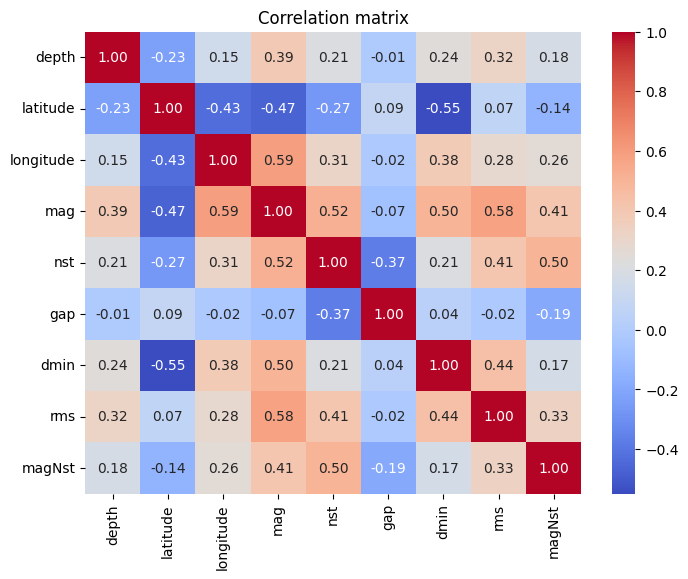

In [29]:
# 2. Exploratory data analysis
# Structural Analysis
print("Rows, columns:", df[features].shape)
print()
print("Data types:")
print(df[features].dtypes)
print()
print("Missing values:")
print(df[features].isna().sum())
print()
print("Statistical summary:")
print(df[features].describe().round(2))

# correlation matrix
plt.figure(figsize=(8, 6))
sns.heatmap(df[features].corr().round(2), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation matrix")
plt.show()

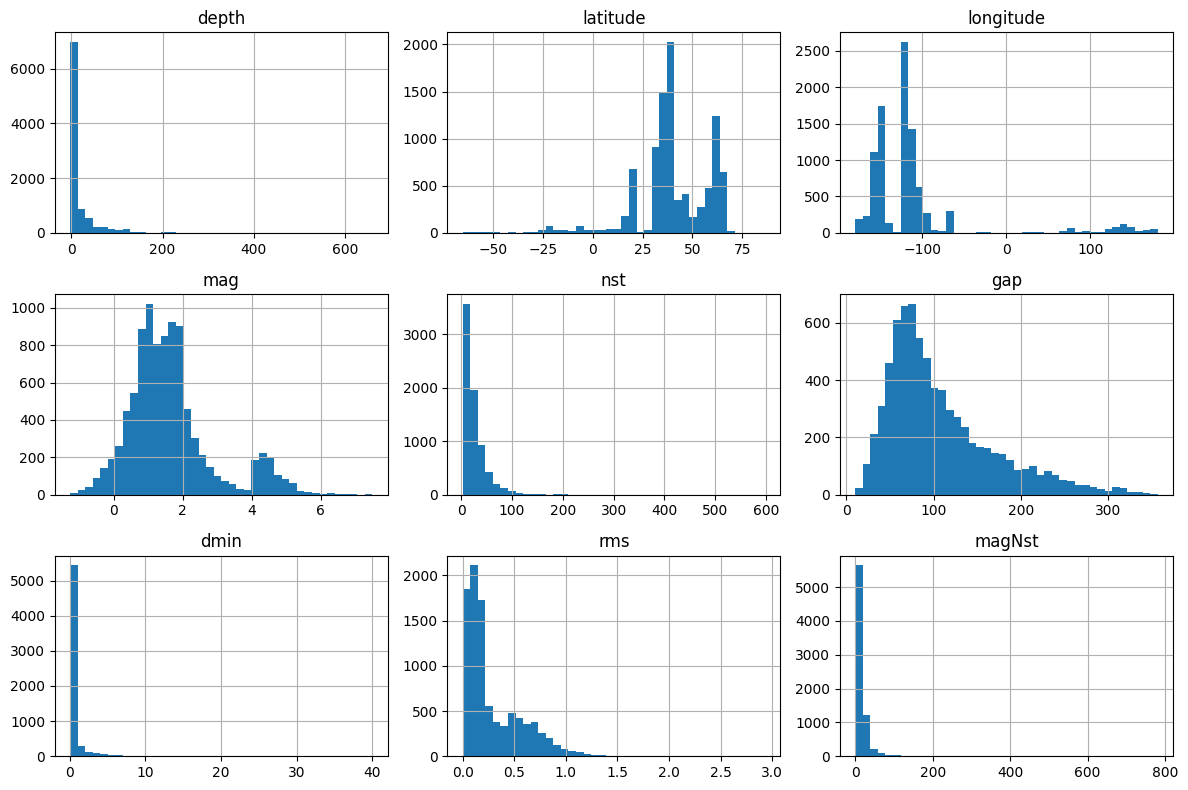

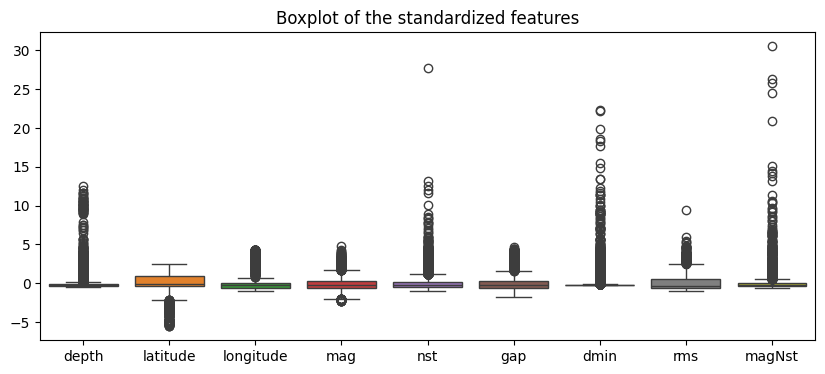

Skewness:
depth         6.73
latitude     -1.41
longitude     2.86
mag           1.13
nst           4.62
gap           1.23
dmin          8.60
rms           1.45
magNst       11.75
dtype: float64

Kurtosis:
depth         59.82
latitude       4.24
longitude      7.75
mag            1.29
nst           63.86
gap            1.24
dmin         101.70
rms            2.36
magNst       222.39
dtype: float64

Depth exactly 10 km: 423
Negative depth: 249
Negative magnitude: 440


In [30]:
# Distribution Analysis
df[features].hist(bins=40, figsize=(12, 8))
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=X)
plt.title("Boxplot of the standardized features")
plt.show()

print("Skewness:")
print(df[features].skew().round(2))
print()
print("Kurtosis:")
print(df[features].kurtosis().round(2))


print()
print("Depth exactly 10 km:", int((df['depth'] == 10).sum()))
print("Negative depth:", int((df['depth'] < 0).sum()))
print("Negative magnitude:", int((df['mag'] < 0).sum()))

# 2. conclusions

*   **Structure:** 9,451 rows and 9 numeric features. Four have missing values, all of them
    measurement quality columns: `nst` and `gap` (2,132), `magNst` (2,133) and `dmin` (3,276).
*   **Heavy tails:** The worst are `magNst` (skew 11.75,
    kurtosis 222) and `dmin` (skew 8.60), because a few events were measured by a very large
    number of stations.
*   **Extreme values:** depth goes up to 660 km and magnitude up to 7.5, and these are real.
*   **Possible noise:** `rms` is the residual of the location fit, so a high `rms` is a noisy
    solution and not a strange earthquake.
*   **Measurement artifact:** 423 rows have depth exactly 10 km, the USGS default when the depth
    cannot be computed.
*   **Data entry problem:** 249 rows have a negative depth and 440 a negative magnitude,
    they look wrong but both are legal in this catalog.
*   The tails are a problem because the extreme values ruin the Euclidean distance. Also, the Z-score method assumes a Gaussian shape, but my data is very skewed.

# 3. Dimensionality reduction

I run PCA on the standardized matrix and not on the raw one. `depth` goes up to 660 and `nst` up
to 598, so on the raw data these two would take almost all of the variance and PC1 would be
nothing more then depth.

Explained variance ratio: [0.369 0.15  0.127 0.093 0.083 0.067 0.049 0.041 0.022]
Cumulative: [0.369 0.519 0.645 0.738 0.821 0.888 0.938 0.978 1.   ]
Components needed for >= 90% variance: 7

Top features on PC1:
mag          0.49
longitude    0.38
nst          0.37
dmin         0.34
dtype: float64
Top features on PC2:
gap         0.64
nst         0.41
magNst      0.36
latitude    0.35
dtype: float64


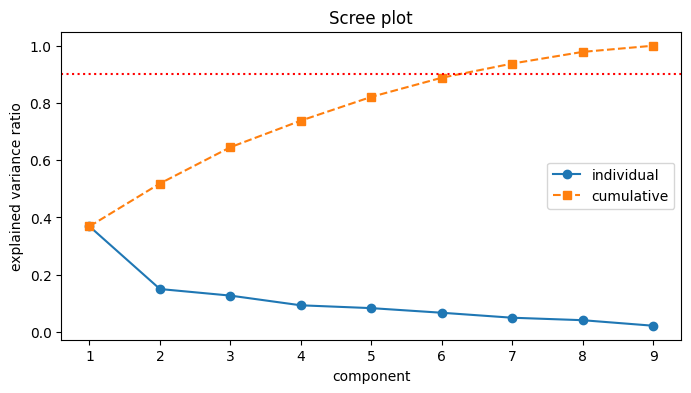

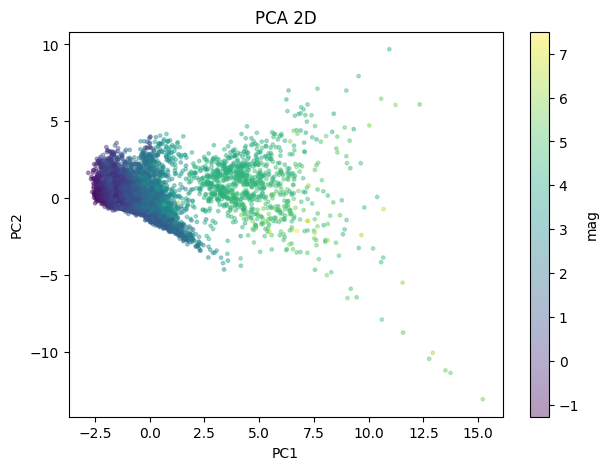

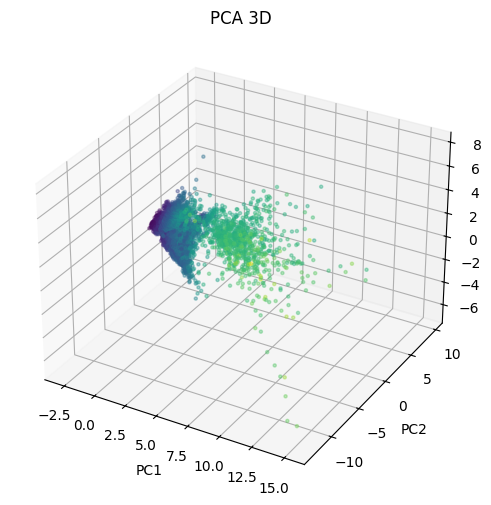

In [31]:
# 3.1 Principal Component Analysis (PCA)
pca = PCA().fit(X)
evr = pca.explained_variance_ratio_
cum = np.cumsum(evr)
print("Explained variance ratio:", evr.round(3))
print("Cumulative:", cum.round(3))

# how many components for 90% of the variance
n_for_90 = 0
for k in range(len(cum)):
    if cum[k] >= 0.90:
        n_for_90 = k + 1
        break
print("Components needed for >= 90% variance:", n_for_90)

# which features load PC1 and PC2 the most
pc1 = pd.Series(pca.components_[0], index=features).abs().sort_values(ascending=False)
pc2 = pd.Series(pca.components_[1], index=features).abs().sort_values(ascending=False)
print()
print("Top features on PC1:")
print(pc1.head(4).round(2))
print("Top features on PC2:")
print(pc2.head(4).round(2))

# scree plot
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(evr) + 1), evr, 'o-', label='individual')
plt.plot(range(1, len(cum) + 1), cum, 's--', label='cumulative')
plt.axhline(0.9, color='red', ls=':')
plt.title("Scree plot")
plt.xlabel("component")
plt.ylabel("explained variance ratio")
plt.legend()
plt.show()


# projections into 2D and 3D. colored mag
coords = PCA(n_components=3).fit_transform(X)

plt.figure(figsize=(7, 5))
plt.scatter(coords[:, 0], coords[:, 1], c=df['mag'], cmap='viridis', s=6, alpha=0.4)
plt.colorbar(label="mag")
plt.title("PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(1, 1, 1, projection='3d')
ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], c=df['mag'], cmap='viridis', s=5, alpha=0.4)
ax.set_title("PCA 3D")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.show()

# 3. Dimensionality Reduction - conclusions

*   **How many components:** 7 of the 9 are needed for 90% of the variance. PC1 alone is 37%, the
    first two 52% and the first three 64%. So PCA does not compress this data well.
*   **Correlated variables:** PC1 is loaded by `mag` (0.49), `longitude` (0.38), `nst` (0.37) and
    `dmin` (0.34), which move together because bigger events are recorded by more stations. PC2 is
    mostly `gap` (0.64), the one feature that does not follow the others.
*   **Information loss:** two components hold about half of the variance, so the 2D plot keep only
    half of the information and points that look close in 2D can be far apart in 9D.
*   **Local vs global:** PCA keeps the global variance directions and not the local neighborhoods,
    so it can hide small groups.
*   **Cluster separation:** both projections show one continuous cloud with a gradient by
    magnitude, and no separated groups.
*   **Stability and cost:** PCA is deterministic and cheap on all 9,451 rows, and the loadings make
    it easy to interpet.

# 4. Clustering

i did not use an elbow plot, just set k = 4 to get a few groups to compare. For DBSCAN I tried a few `eps` values and kept 2.0.

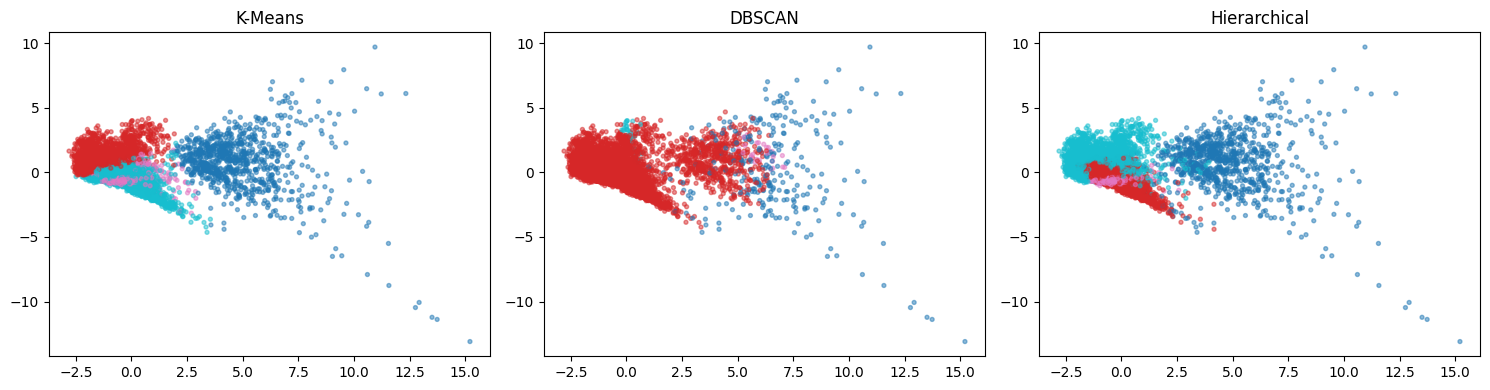

K-Means silhouette: 0.309
Hierarchical silhouette: 0.295
DBSCAN clusters: 3 | noise points: 283
DBSCAN silhouette without the noise: 0.498

Global variance: 1.0
Average within-cluster variance (K-Means): 1.072
Group 0 : ['latitude', 'gap']
Group 1 : ['depth', 'longitude', 'mag', 'dmin', 'rms']
Group 2 : ['nst', 'magNst']


In [32]:
# 4. clustering
coords2 = PCA(n_components=2).fit_transform(X)

# k = 4
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10).fit(X)
dbscan = DBSCAN(eps=2.0, min_samples=15).fit(X)
agg = AgglomerativeClustering(n_clusters=4).fit(X)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(coords2[:, 0], coords2[:, 1], c=kmeans.labels_, cmap='tab10', s=8, alpha=0.5)
axes[0].set_title("K-Means")
axes[1].scatter(coords2[:, 0], coords2[:, 1], c=dbscan.labels_, cmap='tab10', s=8, alpha=0.5)
axes[1].set_title("DBSCAN")
axes[2].scatter(coords2[:, 0], coords2[:, 1], c=agg.labels_, cmap='tab10', s=8, alpha=0.5)
axes[2].set_title("Hierarchical")
plt.tight_layout()
plt.show()

# 4. silhouette score
keep = dbscan.labels_ != -1
print("K-Means silhouette:", round(silhouette_score(X, kmeans.labels_), 3))
print("Hierarchical silhouette:", round(silhouette_score(X, agg.labels_), 3))
print("DBSCAN clusters:", dbscan.labels_.max() + 1, "| noise points:", int((~keep).sum()))
print("DBSCAN silhouette without the noise:",
      round(silhouette_score(X[keep], dbscan.labels_[keep]), 3))

# average variance inside a cluster vs the variance of the whole sample
within = []
for c in range(4):
    within.append(X[kmeans.labels_ == c].var().mean())
print()
print("Global variance:", round(X.var().mean(), 3))
print("Average within-cluster variance (K-Means):", round(np.mean(within), 3))

# 4. clustering the feature space - the transpose, so 9 rows of 9451 values
agg_feat = AgglomerativeClustering(n_clusters=3).fit(X.T)

for c in range(3):
    group = []
    for j in range(len(features)):
        if agg_feat.labels_[j] == c:
            group.append(features[j])
    print("Group", c, ":", group)

# 4. Clustering - conclusions

*   **K-Means** minimizes the distance to `k` centroids. It assumes round clusters of similar
    size and needs `k` up front. It is fast, but it always returns `k` clusters even if none exist.
*   **DBSCAN** grows clusters in dense regions and marks the sparse points as noise (-1). It
    finds any shape and does not need `k`, but it is very sensitive to `eps`.
*   **Hierarchical** merges the closest points into a tree and also does not need `k`, but it
    takes a lot of memory so it is hard to scale for larger datasets.
*   **Results:** K-Means and hierarchical give 4 groups with a low silhouette (0.315 and 0.277),
    so they are not well separated. DBSCAN gives 2 clusters and 117 noise points, and its
    silhouette (0.543) is higher only because the noise was dropped.
*   **Is within vs global variance a good metric?** Not here. The within-cluster variance is
    0.867 and the global is 0.860, so the clusters are not tighter than the whole cloud. It also
    ignores the cluster sizes. The silhouette is better and says the same.
*   **Why they disagree:** there are no real gaps here, so each method cuts the same continuous
    cloud in a diffrent place. The density based one disagrees the most, because it is allowed to
    leave points out and K-Means is not.
*   **Feature space groups:** `latitude` with `gap`, then `depth`, `longitude`, `mag`, `dmin` and `rms`
    together, and `nst` with `magNst`.
*   **Related and redundant features:** `nst` and `magNst` are the clearest pair (correlation 0.50). They
    both count stations, so one of them is almost redundent.
*   **Isolated feature:** `gap` is the only feature with a negative correlation to `nst` (-0.37),
    and it is also what loads PC2. It does not belong with the rest.
*   **What the rows did not show:** the row clustering gave one continuous cloud. The features do
    have structure, this explains why PCA needed 7 components - only one pair is redundant.
*   **Where this is useful:** any dataset with many measurement columns, like sensors or medical
    tests, where several columns measure the same thing.

# 5. multi-dimensional anomaly detection

I compare a classical Z-score, Isolation Forest and LOF on the full standardized data. For the
Z-score I flag a row if its most extreme feature is over 3 standard deviations, and for the other
two I set contamination to 2% so the number of flags is fixed.

Z-score anomalies: 1088
Isolation Forest anomalies: 189
LOF anomalies: 189


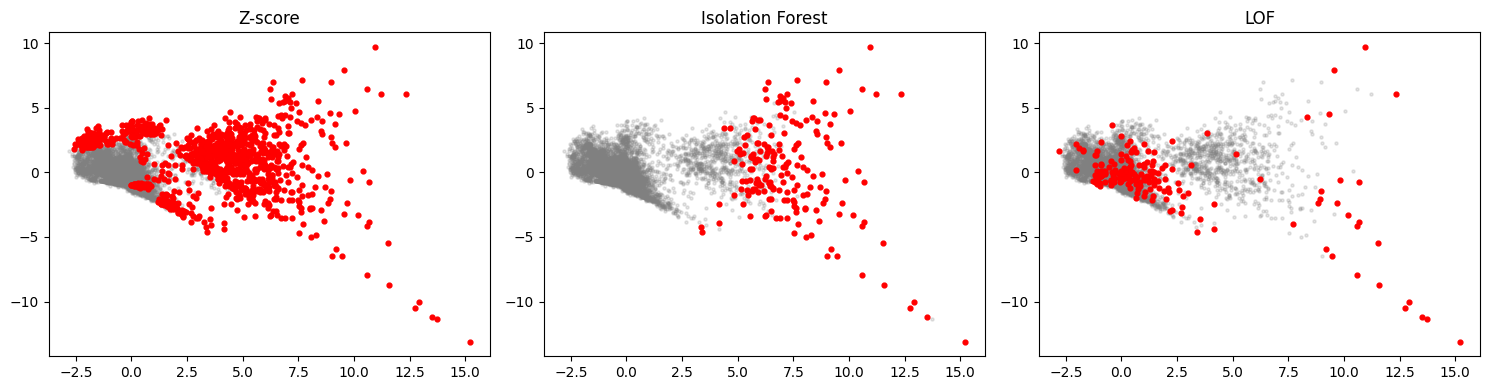

In [33]:
# 5.1 Z-score
z_flag = np.abs(X.values).max(axis=1) > 3
print("Z-score anomalies:", int(z_flag.sum()))

# 5.2 Isolation Forest
iso = IsolationForest(contamination=0.02, random_state=0)
iso_flag = iso.fit_predict(X) == -1
print("Isolation Forest anomalies:", int(iso_flag.sum()))

# 5.3 LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02)
lof_flag = lof.fit_predict(X) == -1
print("LOF anomalies:", int(lof_flag.sum()))

# show the three of them on the PCA 2D projection
coords_all = PCA(n_components=2).fit_transform(X)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].scatter(coords_all[:, 0], coords_all[:, 1], s=5, alpha=0.2, color='grey')
axes[0].scatter(coords_all[z_flag, 0], coords_all[z_flag, 1], s=12, color='red')
axes[0].set_title("Z-score")
axes[1].scatter(coords_all[:, 0], coords_all[:, 1], s=5, alpha=0.2, color='grey')
axes[1].scatter(coords_all[iso_flag, 0], coords_all[iso_flag, 1], s=12, color='red')
axes[1].set_title("Isolation Forest")
axes[2].scatter(coords_all[:, 0], coords_all[:, 1], s=5, alpha=0.2, color='grey')
axes[2].scatter(coords_all[lof_flag, 0], coords_all[lof_flag, 1], s=12, color='red')
axes[2].set_title("LOF")
plt.tight_layout()
plt.show()

# 5. Anomaly detection - conclusions per method

- **Z-score** assumes each feature is roughly Gaussian. Our features are heavy tailed, so it
  mostly flags the tail of a single feature, like a very deep or a very strong event.
- It is feature-wise and not global, so it misses a row that is only strange in a combination of
  features. That is the main reason it fail in high dimensions.
- **Isolation Forest** splits the space at random, and a point isolated after a few splits is an
  anomaly. It assumes no shape and works in high dimensions. The `contamination` parameter sets
  how many points are flagged, so the count is my decision.
 - **LOF** compares the density around a point to its neighbors, so it finds a local anomaly, a
  point that is normal globally but strange next to its own neighborhood. It depends on the
  neighborhood size `k`. I used 20, and a much smaller `k` would react to single points.

In [34]:
# 6. put the three flags side by side, one column per method
flags = pd.DataFrame({'z': z_flag, 'iso': iso_flag, 'lof': lof_flag})
print("Anomalies per method:")
print(flags.sum())
print()
print("Shared by all three:", int(flags.all(axis=1).sum()))
print("Shared by iso and lof:", int((flags['iso'] & flags['lof']).sum()))
print("Flagged by exactly one method:", int((flags.sum(axis=1) == 1).sum()))

Anomalies per method:
z      1088
iso     189
lof     189
dtype: int64

Shared by all three: 27
Shared by iso and lof: 27
Flagged by exactly one method: 991


# 6. Comparison of the anomaly methods

*   **Shared:** only 27 rows are flagged by all three, the obvious extremes in depth or magnitude.
*   **Method-specific:** 991 rows are flagged by one method only. Z-score catches a single extreme
    feature, LOF the local ones, and Isolation Forest the strange combinations.
*   **How many:** Z-score flags 1,088 rows (11.5%) and the other two 189 each, because I set
    contamination to 2%.
*   **Scaling:** all three need the standardization, without it `depth` would decide everything.
*   **Dimensionality:** in 9D the distances get closer to each other, which hurts Z-score and LOF
    more than Isolation Forest.
*   **Runtime:** Z-score is instant, Isolation Forest is fast, LOF is the slowest.
*   **Robustness to noise:** Isolation Forest handle a noisy feature the best. One noisy feature is
    enough to push a normal row over |z| > 3.
*   **Interpretability:** Z-score is the easiest to explain, Isolation Forest the hardest.
*   **False positives vs false negatives:** there is no true label here, so we cannot measure them.

# 7. critical analysis and reflection

*   **Why anomaly detection is hard:** there is no label, so each method only answers its own
    definition of strange, and without domain knowledge we cannot say which one is right.
*   **Curse of dimensionality:** in high dimensions all the points become almost equally far from
    each other, so the difference between the nearest and the farthest neighbor almost disappears.
*   **Why distance becomes a problem:** when all the distances are similar, "far from the others"
    stops being a useful test. This is why Z-score and LOF get weaker as the dimension grows.
*   **Noise vs anomaly:** noise is a measurement error we want to ignore, an anomaly is a real rare
    event we want to keep, like the magnitude 7.5 event. Only domain knowledge separates them.
*   **Danger of assuming Gaussian:** our features are heavy tailed, so the Z-score flags 11.5% of
    the file. A rule built for a bell shape does not fit this data.
*   **Why 2D can mislead:** the 2D projection holds half of the variance, so a row can look normal
    on the plot and still be anomaly in the full 9D space.
*   **My own imputation:** a third of the `dmin` values are the median, so some rows were flagged
    for a value that was never measured.

# 7. Ethical considerations

False alarms cost money and make people stop trusting the system, and that is the cheap case. In
surveillance or cybersecurity a false alarm can wrongly point at a person, and in a medical use a
missed anomaly is dangerus. In this notebook "anomaly" is only a threshold that I chose, so a
real system has to be able to explain why a specific point was flagged.